# Phase 2: lineup simulator

## Setup

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import glob, random
from collections import defaultdict, Counter
from pathlib import Path

DATA_GLOB = "path to XML files"

TERMINAL = (0, 0, 0, 3)

## Helpers

In [55]:
def classify_event(action):
    tok = (action or "").strip().split()
    if not tok:
        return None
    t = tok[0]
    if t in ("1B", "2B", "3B", "HR"):
        return t
    if t in ("BB", "IBB", "HP", "HBP"):
        return "BB"
    return "OUT"

def base_out_state(play):
    return (1 if play.get("first")  else 0,
            1 if play.get("second") else 0,
            1 if play.get("third")  else 0,
            int(play.get("outs") or 0))

def runs_on_play(play):
    r = sum(1 for rn in play.findall("runner") if rn.get("scored") == "1")
    b = play.find("batter")
    if b is not None and b.get("tobase") == "4":
        r += 1
    return r

def outs_on_play(play):
    o = sum(int(rn.get("out") or 0) for rn in play.findall("runner"))
    b = play.find("batter")
    if b is not None:
        o += int(b.get("out") or 0)
    return o

def is_tiebreaker(batting):
    return any("placed on" in (n.get("text") or "") for n in batting.iter("narrative"))

## Parse from P1 but better

Same grouping logic but now tracking batter, event type, and team per PA. 
Deduplicates games by venue/date/time.

In [56]:
def half_inning_rows(batting):
    groups, cur, outs_made = [], None, 0
    for play in batting.findall("play"):
        if play.find("batter") is None and play.find("runner") is None:
            continue
        if int(play.get("outs") or 0) >= 3:
            continue
        b = play.get("batter")
        if cur is None or b != cur["batter"]:
            cur = {"batter": b, "hand": play.get("batprof"),
                   "before": base_out_state(play), "runs": 0, "event": None}
            groups.append(cur)
        cur["runs"] += runs_on_play(play)
        outs_made += outs_on_play(play)
        be = play.find("batter")
        if be is not None and (be.get("action") or "").strip():
            cur["event"] = classify_event(be.get("action"))

    complete = outs_made >= 3
    rows = []
    for i, g in enumerate(groups):
        if i + 1 < len(groups):
            after = groups[i + 1]["before"]
        elif complete:
            after = TERMINAL
        else:
            break
        if g["event"] is None:
            continue
        rows.append({"before": g["before"], "after": after, "runs": g["runs"],
                     "batter": g["batter"], "hand": g["hand"], "event": g["event"]})
    return rows


def parse_game(path, seen):
    try:
        root = ET.parse(path).getroot()
    except ET.ParseError:
        return []
    venue = root.find("venue")
    if venue is None:
        return []
    date = venue.get("date", "")
    game_id = f"{date}_{venue.get('visid', '')}_{venue.get('homeid', '')}_{venue.get('start', '')}"
    if game_id in seen:
        return []
    seen.add(game_id)
    try:
        season = int(date.split("/")[-1])
    except (ValueError, IndexError):
        season = None
    vis_id = venue.get("visid", "")
    home_id = venue.get("homeid", "")

    plays = root.find("plays")
    if plays is None:
        return []
    rows = []
    for inning in plays.findall("inning"):
        for batting in inning.findall("batting"):
            if is_tiebreaker(batting):
                continue
            vh = batting.get("vh")
            team = vis_id if vh == "V" else home_id
            for row in half_inning_rows(batting):
                row["game_id"] = game_id
                row["season"] = season
                row["team"] = team
                rows.append(row)
    return rows


def parse_directory(pattern):
    seen = set()
    rows = []
    for f in sorted(glob.glob(pattern, recursive=True)):
        rows.extend(parse_game(f, seen))
    return rows

### Run the parse

In [65]:
rows = parse_directory(DATA_GLOB)
edf = pd.DataFrame(rows)

print(f"enriched PAs: {len(edf):,}")
print(f"games: {edf['game_id'].nunique():,}")
print(f"distinct players (name + team): {edf.groupby(['batter', 'team']).ngroups:,}")
print(f"seasons: {sorted(edf['season'].dropna().unique().astype(int))}")
print(f"\nevent mix:")
print(edf["event"].value_counts().to_string())
print(f"\nfirst 6 rows:")
print(edf[["batter", "team", "event", "before", "after", "runs"]].head(6).to_string(index=False))

edf.to_pickle("plays_enriched.pkl")

enriched PAs: 162,576
games: 2,092
distinct players (name + team): 2,668
seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

event mix:
event
OUT    100239
BB      26660
1B      25605
2B       6622
HR       2405
3B       1045

first 6 rows:
    batter     team event       before        after  runs
 C. Wiesen JOHNSTOW    1B (0, 0, 0, 0) (1, 0, 0, 0)     0
   M. Vega JOHNSTOW    BB (1, 0, 0, 0) (1, 1, 0, 0)     0
 T. Horvat JOHNSTOW    BB (1, 1, 0, 0) (1, 1, 0, 1)     0
 J. Rogers JOHNSTOW   OUT (1, 1, 0, 1) (0, 1, 1, 2)     0
J. Freeman JOHNSTOW   OUT (0, 1, 1, 2) (0, 0, 0, 3)     0
 B. Buzzeo CHAMPION   OUT (0, 0, 0, 0) (0, 0, 0, 1)     0


## Advancement model

For each `(state, event)` combo, count how often each `(after_state, runs)` outcome
happened. This gives `advancement[state][event]` (the distribution of where runners
end up and how many score, given the base-out state and what kind of hit/walk/out it was)

In [58]:
def build_advancement(rows):
    counts = defaultdict(lambda: defaultdict(int))
    for r in rows:
        counts[(r["before"], r["event"])][(r["after"], r["runs"])] += 1
    adv = {}
    for key, outcomes in counts.items():
        total = sum(outcomes.values())
        results = list(outcomes.keys())
        weights = [c / total for c in outcomes.values()]
        adv[key] = (results, weights)
    return adv

# if loading from pickle instead of re-parsing:
rows = pd.read_pickle("plays_enriched.pkl").to_dict("records")

advancement = build_advancement(rows)
print(f"advancement combos populated: {len(advancement)} / {24 * 6} possible")

# league-average event profile (this becomes the prior for player rates in section 5)
total_pa = len(rows)
event_counts = Counter(r["event"] for r in rows)
league_avg = {ev: event_counts[ev] / total_pa for ev in ["OUT","BB","1B","2B","3B","HR"]}
print(f"\nleague-average event profile:")
for ev, rate in league_avg.items():
    print(f"  {ev:>3}: {rate:.3f}")

# example: what happens on a single with a runner on first, nobody out?
key = ((1,0,0,0), "1B")
results, weights = advancement[key]
print(f"\nexample — single with runner on 1st, 0 out:")
for (after, runs), p in sorted(zip(results, weights), key=lambda x: -x[1])[:5]:
    print(f"  -> {after}  +{runs} run(s)  p={p:.3f}")

advancement combos populated: 144 / 144 possible

league-average event profile:
  OUT: 0.617
   BB: 0.164
   1B: 0.157
   2B: 0.041
   3B: 0.006
   HR: 0.015

example — single with runner on 1st, 0 out:
  -> (1, 1, 0, 0)  +0 run(s)  p=0.647
  -> (1, 0, 1, 0)  +0 run(s)  p=0.212
  -> (1, 0, 0, 0)  +1 run(s)  p=0.053
  -> (1, 0, 0, 1)  +0 run(s)  p=0.036
  -> (0, 1, 1, 0)  +0 run(s)  p=0.024


## Player event rates (regressed)

Blend each player's observed rates toward the league average. 
REGRESS_PA controls how much — higher = more conservative.

In [59]:
REGRESS_PA = 200  # pseudo-PAs of league-average performance blended into each player

def compute_player_rates(edf, league_avg, regress_pa=REGRESS_PA, season=None):
    df = edf if season is None else edf[edf["season"] == season]
    events = ["OUT", "BB", "1B", "2B", "3B", "HR"]
    rates = {}
    for (batter, team), grp in df.groupby(["batter", "team"]):
        n = len(grp)
        observed = grp["event"].value_counts().to_dict()
        player = {}
        for ev in events:
            obs = observed.get(ev, 0)
            player[ev] = (obs + regress_pa * league_avg[ev]) / (n + regress_pa)
        player["pa"] = n
        rates[(batter, team)] = player
    return rates

player_rates = compute_player_rates(edf, league_avg)
print(f"players with rates: {len(player_rates):,}")

# show a high-PA player's rates vs league average
top = min(player_rates.items(), key=lambda x: x[1]["pa"])
print(f"\n{top[0][0]} ({top[0][1]}) — {top[1]['pa']} PAs:")
print(f"  {'event':>5}  {'regressed':>9}  {'league':>7}")
for ev in ["OUT", "BB", "1B", "2B", "3B", "HR"]:
    print(f"  {ev:>5}  {top[1][ev]:>9.3f}  {league_avg[ev]:>7.3f}")

players with rates: 2,668

A. Brock (CAPE CAT) — 1 PAs:
  event  regressed   league
    OUT      0.618    0.617
     BB      0.163    0.164
     1B      0.157    0.157
     2B      0.041    0.041
     3B      0.006    0.006
     HR      0.015    0.015


## Lineup simulator

The new sim loop. Takes a lineup of 9 players and rotates through them. Each plate
appearance: draw the event from the current batter's rates, draw the runner movement
from the advancement model, update the state, rotate to the next batter.

The batting-order pointer persists across innings (the next inning leads off with
whoever was due up, not always the \#1 hitter)

In [60]:
def sim_lineup_inning(lineup, pointer, player_rates, advancement):
    state = (0, 0, 0, 0)
    runs = 0
    while state[3] < 3:
        batter_key = lineup[pointer]
        rates = player_rates[batter_key]
        events = ["OUT", "BB", "1B", "2B", "3B", "HR"]
        weights = [rates[ev] for ev in events]
        event, = random.choices(events, weights=weights, k=1)
        results, adv_weights = advancement[(state, event)]
        (next_state, scored), = random.choices(results, weights=adv_weights, k=1)
        runs += scored
        state = next_state
        pointer = (pointer + 1) % 9
    return runs, pointer

def sim_lineup_game(lineup, player_rates, advancement, innings=9):
    pointer = 0
    total = 0
    for _ in range(innings):
        inning_runs, pointer = sim_lineup_inning(lineup, pointer, player_rates, advancement)
        total += inning_runs
    return total

def sim_lineup(lineup, player_rates, advancement, n_games=10000):
    return [sim_lineup_game(lineup, player_rates, advancement) for _ in range(n_games)]

# demo: grab the top 9 hitters by PA from one team
demo_team = max(edf["team"].value_counts().index)  # most-represented team
team_players = [(k, v) for k, v in player_rates.items() if k[1] == demo_team]
lineup = [p[0] for p in sorted(team_players, key=lambda x: -x[1]["pa"])[:9]]

print(f"demo lineup ({demo_team}):")
for i, key in enumerate(lineup, 1):
    print(f"  {i}. {key[0]:15} {player_rates[key]['pa']:>4} PA")

results = sim_lineup(lineup, player_rates, advancement, n_games=20000)
print(f"\n{len(results):,} games simulated")
print(f"mean runs/game: {sum(results)/len(results):.2f}")
print(f"shutouts: {results.count(0)/len(results)*100:.1f}%")
print(f"10+ run games: {sum(1 for r in results if r>=10)/len(results)*100:.1f}%")

demo lineup (WEST VIR):
  1. E. Leon          202 PA
  2. A. Christie      188 PA
  3. B. Lazaris       187 PA
  4. D. Hooper        162 PA
  5. S. Butler        161 PA
  6. H. Skipper       126 PA
  7. C. Tweten        121 PA
  8. B. Riebock        95 PA
  9. N. Canterbur      95 PA

20,000 games simulated
mean runs/game: 7.01
shutouts: 1.5%
10+ run games: 24.4%


## Validate against the RE matrix

Feed the simulator 9 copies of a league-average hitter. The output should match
the RE matrix. 

In [61]:
# create a league-average "player" and make a lineup of 9 copies
avg_key = ("League Average", "LEAGUE")
player_rates[avg_key] = {**league_avg, "pa": 999}
avg_lineup = [avg_key] * 9

avg_results = sim_lineup(avg_lineup, player_rates, advancement, n_games=50000)
mean_rpg = sum(avg_results) / len(avg_results)
print(f"league-average lineup: {mean_rpg:.2f} runs/game")
print(f"per inning: {mean_rpg/9:.3f}")
print(f"phase-1 RE (bases empty, 0 out): 0.759")

league-average lineup: 6.90 runs/game
per inning: 0.767
phase-1 RE (bases empty, 0 out): 0.759


## Try real lineups

Input actual Cornbelters lineups, compare run distributions across different batting
orders, see how much (or how little) the order matters with current roster.

In [62]:
TEAMS = ["NOR", "NORMAL C"]
season_rates = compute_player_rates(edf, league_avg, season=2026)
team_players = [(k, v) for k, v in season_rates.items() if k[1] in TEAMS]
team_players.sort(key=lambda x: -x[1]["pa"])

print(f"Cornbelters 2026 roster:")
for i, (key, r) in enumerate(team_players[:12], 1):
    print(f"  {i:>2}. {key[0]:15} {r['pa']:>3} PA  OUT={r['OUT']:.3f}  1B={r['1B']:.3f}  HR={r['HR']:.3f}")

Cornbelters 2026 roster:
   1. Tyler Thompson   51 PA  OUT=0.615  1B=0.173  HR=0.012
   2. Jackson Stanek   50 PA  OUT=0.613  1B=0.162  HR=0.016
   3. Nolan McCrossin  47 PA  OUT=0.609  1B=0.176  HR=0.012
   4. Ben Voegele      42 PA  OUT=0.605  1B=0.159  HR=0.020
   5. Carter Bleakney  33 PA  OUT=0.606  1B=0.174  HR=0.017
   6. Michael Kuska    33 PA  OUT=0.606  1B=0.161  HR=0.013
   7. Dylan Coty       32 PA  OUT=0.622  1B=0.153  HR=0.017
   8. Eli Kieser       32 PA  OUT=0.609  1B=0.170  HR=0.013
   9. Filippo Baratta  29 PA  OUT=0.635  1B=0.146  HR=0.013
  10. Parker Heistand  23 PA  OUT=0.629  1B=0.155  HR=0.013
  11. John Nisbet      20 PA  OUT=0.624  1B=0.152  HR=0.013
  12. Dillon Romano    17 PA  OUT=0.628  1B=0.159  HR=0.014


In [63]:
def find_best_lineup(players, n_tries=300, games_per=5000):
    keys = [cb[n] for n in players]
    best_mean, best_order = 0, None
    worst_mean, worst_order = 999, None
    
    for i in range(n_tries):
        order = keys.copy()
        random.shuffle(order)
        results = sim_lineup(order, season_rates, advancement, n_games=games_per)
        mean = sum(results) / len(results)
        if mean > best_mean:
            best_mean, best_order = mean, [k[0] for k in order]
        if mean < worst_mean:
            worst_mean, worst_order = mean, [k[0] for k in order]
        if (i + 1) % 100 == 0:
            print(f"  tested {i+1}/{n_tries}...")
    
    print(f"\nbest of {n_tries}:  {best_mean:.2f} runs/game")
    for i, name in enumerate(best_order, 1):
        print(f"  {i}. {name}")
    print(f"\nworst of {n_tries}: {worst_mean:.2f} runs/game")
    print(f"gap: {best_mean - worst_mean:.2f} runs/game")

players = [
    "Nolan McCrossin", "Ben Voegele", "Tyler Thompson",
    "Jackson Stanek", "Carter Bleakney", "Eli Kieser",
    "Michael Kuska", "Dylan Coty", "Filippo Baratta"
]
find_best_lineup(players)

  tested 100/300...
  tested 200/300...
  tested 300/300...

best of 300:  7.25 runs/game
  1. Nolan McCrossin
  2. Michael Kuska
  3. Dylan Coty
  4. Ben Voegele
  5. Eli Kieser
  6. Filippo Baratta
  7. Tyler Thompson
  8. Carter Bleakney
  9. Jackson Stanek

worst of 300: 6.92 runs/game
gap: 0.33 runs/game


## Expected Stats from TrackMan Model


In [ ]:
# Load expected rates
XRATES_PATH = "csv with expected rates"

def load_xstats_rates(csv_path):
    df = pd.read_csv(csv_path)
    rates = {}
    for _, row in df.iterrows():
        key = (row["batter"], row["team"])
        rates[key] = {
            "OUT": row["OUT"],
            "BB":  row["BB"],
            "1B":  row["1B"],
            "2B":  row["2B"],
            "3B":  row["3B"],
            "HR":  row["HR"],
            "pa":  int(row["pa"]),
        }
    return rates

xrates = load_xstats_rates(XRATES_PATH)
print(f"Loaded expected rates for {len(xrates)} players")


# League-average fallback for players not in the CSV
# (uses the league_avg dict already built in Section 4)
xrates_league_fallback = {**league_avg, "pa": 0}

def get_rate(key, rates_dict):
    """Look up a player's rates; fall back to league-average if missing."""
    if key in rates_dict:
        return rates_dict[key]
    print(f" {key[0]} not in expected rates — using league average")
    return xrates_league_fallback

Loaded expected rates for 105 players


In [74]:
# Compare observed vs expected for Cornbelters 

cor_team = "NOR_COR"
cor_players = {k: v for k, v in xrates.items() if k[1] == cor_team}

# Also get observed rates from the XML parse (Section 5) for comparison
# Need to map names: TrackMan "Last, First" -> XML "First Last"
def trackman_to_xml_name(tm_name):
    parts = tm_name.split(", ")
    if len(parts) == 2:
        return f"{parts[1].strip()} {parts[0].strip()}"
    return tm_name

print(f"{'Player':>20}  {'PA':>3}  {'':>5}  {'OUT':>6}  {'BB':>6}  {'1B':>6}  {'2B':>6}  {'HR':>6}")
print("-" * 75)

for key in sorted(cor_players, key=lambda k: -cor_players[k]["pa"]):
    xr = cor_players[key]
    xml_name = trackman_to_xml_name(key[0])

    # Try to find player in the observed rates from the XML parse
    obs_key = None
    for k in player_rates:
        if k[0] == xml_name or k[0].replace(" ", "") == xml_name.replace(" ", ""):
            obs_key = k
            break

    print(f"{key[0]:>20}  {xr['pa']:>3}  xRate  {xr['OUT']:.3f}  {xr['BB']:.3f}  {xr['1B']:.3f}  {xr['2B']:.3f}  {xr['HR']:.3f}")
    if obs_key and obs_key in player_rates:
        obs = player_rates[obs_key]
        print(f"{'':>20}  {obs['pa']:>3}  obsRt  {obs['OUT']:.3f}  {obs['BB']:.3f}  {obs['1B']:.3f}  {obs['2B']:.3f}  {obs['HR']:.3f}")
    print()

              Player   PA            OUT      BB      1B      2B      HR
---------------------------------------------------------------------------
     Thompson, Tyler   50  xRate  0.590  0.060  0.307  0.038  0.001
                       51  obsRt  0.615  0.151  0.173  0.044  0.012

     Stanek, Jackson   49  xRate  0.507  0.204  0.180  0.072  0.022
                       50  obsRt  0.613  0.163  0.162  0.041  0.016

    McCrossin, Nolan   47  xRate  0.575  0.149  0.231  0.040  0.004
                       47  obsRt  0.609  0.157  0.176  0.037  0.012

        Voegele, Ben   40  xRate  0.545  0.225  0.140  0.040  0.047
                       42  obsRt  0.605  0.169  0.159  0.038  0.020

    Baratta, Filippo   33  xRate  0.728  0.152  0.098  0.013  0.003
                       29  obsRt  0.635  0.165  0.146  0.036  0.013

    Bleakney, Carter   33  xRate  0.561  0.061  0.277  0.080  0.019
                       33  obsRt  0.606  0.149  0.174  0.048  0.017

         Coty, Dylan   32  xR

In [71]:
# Simulate with expected rates

# Build the Cornbelters lineup using TrackMan name format
cor_lineup = [
    ("McCrossin, Nolan",  "NOR_COR"),
    ("Voegele, Ben",      "NOR_COR"),
    ("Thompson, Tyler",   "NOR_COR"),
    ("Stanek, Jackson",   "NOR_COR"),
    ("Bleakney, Carter",  "NOR_COR"),
    ("Kuska, Michael",    "NOR_COR"),
    ("Coty, Dylan",       "NOR_COR"),
    ("Baratta, Filippo",  "NOR_COR"),
]

# Only 8 Cornbelters hit the 30 PA minimum in TrackMan data.
cor_lineup.append(("Kieser, Eli", "NOR_COR"))
xrates[("Kieser, Eli", "NOR_COR")] = xrates_league_fallback

print("Cornbelters lineup (expected rates):")
for i, key in enumerate(cor_lineup, 1):
    r = get_rate(key, xrates)
    print(f"  {i}. {key[0]:20} {r['pa']:>3} PA  xOUT={r['OUT']:.3f}  x1B={r['1B']:.3f}  xHR={r['HR']:.3f}")

# Simulate
x_results = sim_lineup(cor_lineup, xrates, advancement, n_games=20000)
print(f"\n{len(x_results):,} games simulated (expected rates)")
print(f"mean runs/game: {sum(x_results)/len(x_results):.2f}")
print(f"shutouts: {x_results.count(0)/len(x_results)*100:.1f}%")
print(f"10+ run games: {sum(1 for r in x_results if r >= 10)/len(x_results)*100:.1f}%")

Cornbelters lineup (expected rates):
  1. McCrossin, Nolan      47 PA  xOUT=0.575  x1B=0.231  xHR=0.004
  2. Voegele, Ben          40 PA  xOUT=0.545  x1B=0.140  xHR=0.047
  3. Thompson, Tyler       50 PA  xOUT=0.590  x1B=0.307  xHR=0.001
  4. Stanek, Jackson       49 PA  xOUT=0.507  x1B=0.180  xHR=0.022
  5. Bleakney, Carter      33 PA  xOUT=0.561  x1B=0.277  xHR=0.019
  6. Kuska, Michael        32 PA  xOUT=0.568  x1B=0.188  xHR=0.000
  7. Coty, Dylan           32 PA  xOUT=0.712  x1B=0.111  xHR=0.021
  8. Baratta, Filippo      33 PA  xOUT=0.728  x1B=0.098  xHR=0.003
  9. Kieser, Eli            0 PA  xOUT=0.617  x1B=0.157  xHR=0.015

20,000 games simulated (expected rates)
mean runs/game: 7.92
shutouts: 0.9%
10+ run games: 31.6%


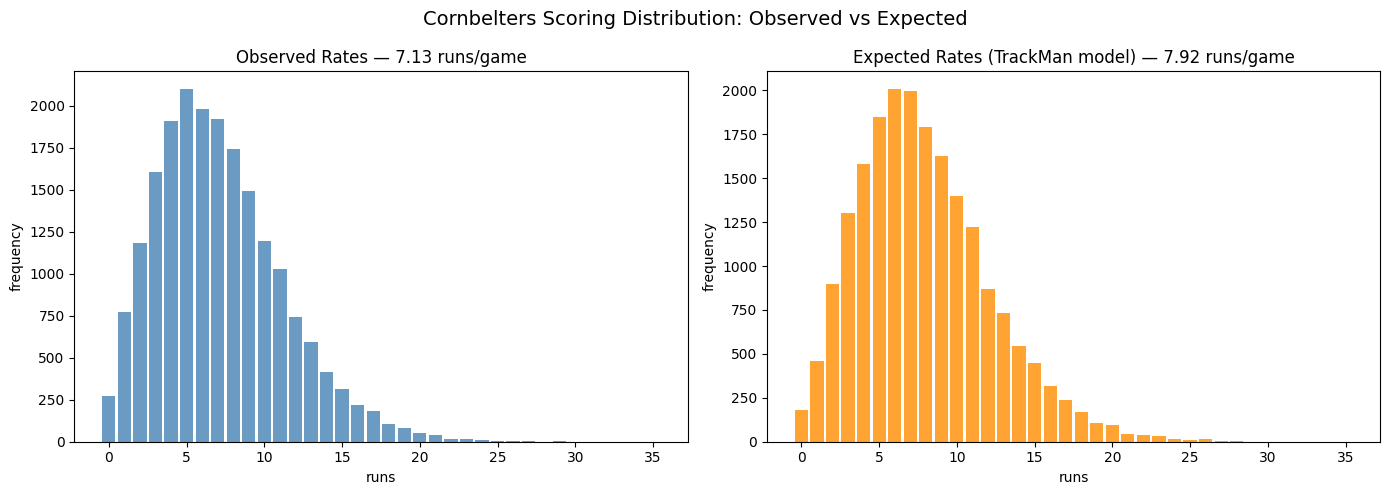


Expected rates project 0.79 more runs/game than observed rates.


In [ ]:
# Compare observed vs expected sim results

import matplotlib.pyplot as plt

# Run the same lineup through observed rates for comparison
# (need to map TrackMan names back to XML names for player_rates)
obs_lineup = []
for tm_key in cor_lineup:
    xml_name = trackman_to_xml_name(tm_key[0])
    found = None
    for k in player_rates:
        if k[0] == xml_name or k[0].replace(" ", "") == xml_name.replace(" ", ""):
            found = k
            break
    obs_lineup.append(found if found else tm_key)

obs_results = sim_lineup(obs_lineup, player_rates, advancement, n_games=20000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_runs = max(max(x_results), max(obs_results)) + 2

axes[0].hist(obs_results, bins=range(0, max_runs), align="left", rwidth=0.85, alpha=0.8, color="steelblue")
axes[0].set_title(f"Observed Rates — {sum(obs_results)/len(obs_results):.2f} runs/game")
axes[0].set_xlabel("runs"); axes[0].set_ylabel("frequency")

axes[1].hist(x_results, bins=range(0, max_runs), align="left", rwidth=0.85, alpha=0.8, color="darkorange")
axes[1].set_title(f"Expected Rates (TrackMan model) — {sum(x_results)/len(x_results):.2f} runs/game")
axes[1].set_xlabel("runs"); axes[1].set_ylabel("frequency")

plt.suptitle("Cornbelters Scoring Distribution: Observed vs Expected", fontsize=14)
plt.tight_layout()
plt.show()

x_mean = sum(x_results)/len(x_results)
o_mean = sum(obs_results)/len(obs_results)
diff = x_mean - o_mean
direction = "more" if diff > 0 else "fewer"
print(f"\nExpected rates project {abs(diff):.2f} {direction} runs/game than observed rates.")